# Super vactor machine -
-  Hyper plane jo mere dataset ko completly segregaate kare.
-  Attribute selection Measure(ASM)  - ISASE BEST HYPER plane nikalate hai .
- Fastest comparision to KNN . 

kernal = 
1. linear
2. Poly
3. RBF -->Radial Basis Function Poly ka advance .

Sigmoid 

In [2]:
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
iris_df = pd.read_csv(r'D:\AI & ML\Machine_Learning_19\Dataset\iris.csv')
iris_df.head(4)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa


# EDA  

In [4]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
iris_df.select_dtypes(include = 'object')

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
...,...
145,virginica
146,virginica
147,virginica
148,virginica


In [7]:
cat_col = iris_df['species'].unique()
cat_col

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [8]:
from sklearn.preprocessing import LabelEncoder
iris_df['species'] = LabelEncoder().fit_transform(iris_df['species'])

iris_df.tail(9)

,sepal_length,sepal_width,petal_length,petal_width,species
141,6.9,3.1,5.1,2.3,2
142,5.8,2.7,5.1,1.9,2
143,6.8,3.2,5.9,2.3,2
144,6.7,3.3,5.7,2.5,2
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [9]:
Dependent = iris_df.iloc[:,-1]
Dependent

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int32

In [10]:
Independent = iris_df.drop('species',axis=1)
Independent

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(Independent,Dependent, test_size=0.3, random_state=42,stratify=Dependent)

In [12]:
from sklearn.svm import SVC

svm_model = SVC().fit(X_train,Y_train)

In [13]:
svc_predict = svm_model.predict(X_test)
svc_predict

array([2, 1, 2, 1, 2, 2, 1, 1, 0, 2, 0, 0, 2, 2, 0, 2, 1, 0, 0, 0, 1, 0,
       1, 2, 2, 1, 1, 1, 1, 0, 2, 2, 1, 0, 2, 0, 0, 0, 0, 2, 1, 0, 1, 2,
       1])

In [14]:
DF = pd.DataFrame({'Actual':Y_test,
                   "Predicted":svc_predict})
DF.head(5)

,Actual,Predicted
107,2,2
63,1,1
133,2,2
56,1,1
127,2,2


In [15]:
from sklearn.metrics import r2_score

r2_score(Y_test,svc_predict)*100

93.33333333333333

In [16]:
from sklearn.metrics import confusion_matrix
confu_mat = confusion_matrix(Y_test,svc_predict)
print(confu_mat)

[[15  0  0]
 [ 0 14  1]
 [ 0  1 14]]


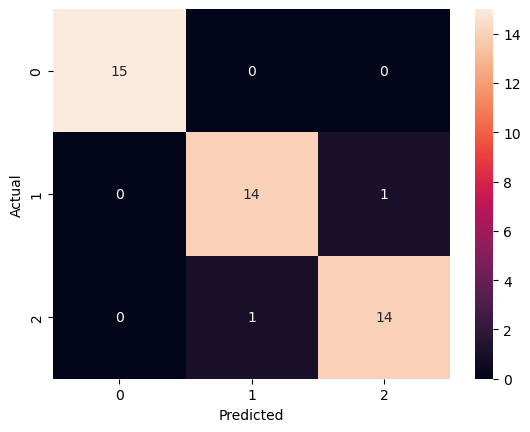

In [17]:
sns.heatmap(confusion_matrix(Y_test,svc_predict),annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [18]:
import pickle

with open('SVM_deployAPP.pkl','wb') as file:
    pickle.dump(svm_model,file)